# AI_ML_Task2_Model_Comparison.ipynb
## Task 2: House Price Prediction System

This notebook demonstrates a comparative analysis of three machine learning models for predicting house prices using the California Housing Dataset.

### 1. Data Loading & Preparation
First, we import the necessary libraries and load the dataset into a pandas DataFrame.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn import metrics

# Load dataset
cal_housing = fetch_california_housing()
data = pd.DataFrame(cal_housing.data, columns=cal_housing.feature_names)
data['HousePrice'] = cal_housing.target

# Display head
display(data.head())

# Separate features and target
X = data.drop('HousePrice', axis=1)
y = data['HousePrice']

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### 2. Feature Scaling & Splitting
Scaling ensures that features with larger ranges do not dominate the learning process.

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 16512
Testing set size: 4128


### 3. Model Training
We initialize and train Linear Regression (Baseline), Ridge (Regularized), and a Decision Tree Regressor.

In [14]:
lr_model = LinearRegression().fit(X_train, y_train)
ridge_model = Ridge(alpha=1.0).fit(X_train, y_train)
dtree_model = DecisionTreeRegressor(max_depth=5).fit(X_train, y_train)

print("Models successfully trained.")

Models successfully trained.


### 4. Model Evaluation & Comparison Table
We calculate RMSE and R-squared scores to identify the best performing model.

In [15]:
def evaluate(model, X_test, y_test):
    preds = model.predict(X_test)
    rmse = np.sqrt(metrics.mean_squared_error(y_test, preds))
    r2 = metrics.r2_score(y_test, preds)
    return rmse, r2

models = {
    "Linear Regression": lr_model,
    "Ridge Regression": ridge_model,
    "Decision Tree": dtree_model
}

results = []
for name, model in models.items():
    rmse, r2 = evaluate(model, X_test, y_test)
    results.append({"Model": name, "RMSE": rmse, "R2 Score": r2})

comparison_df = pd.DataFrame(results)
display(comparison_df)

best_model_row = comparison_df.loc[comparison_df['R2 Score'].idxmax()]
print(f"Best Model: {best_model_row['Model']} with R2 Score: {best_model_row['R2 Score']:.4f}")

,Model,RMSE,R2 Score
0,Linear Regression,0.745581,0.575788
1,Ridge Regression,0.745554,0.575819
2,Decision Tree,0.724234,0.599732


Best Model: Decision Tree with R2 Score: 0.5997


### 5. Visual Validation & Optional Enhancements
Visualizing predictions for the best model and saving it for future use.

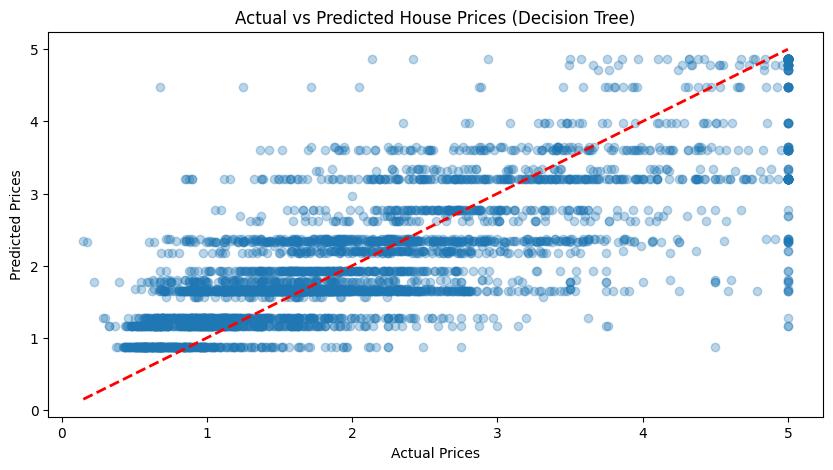

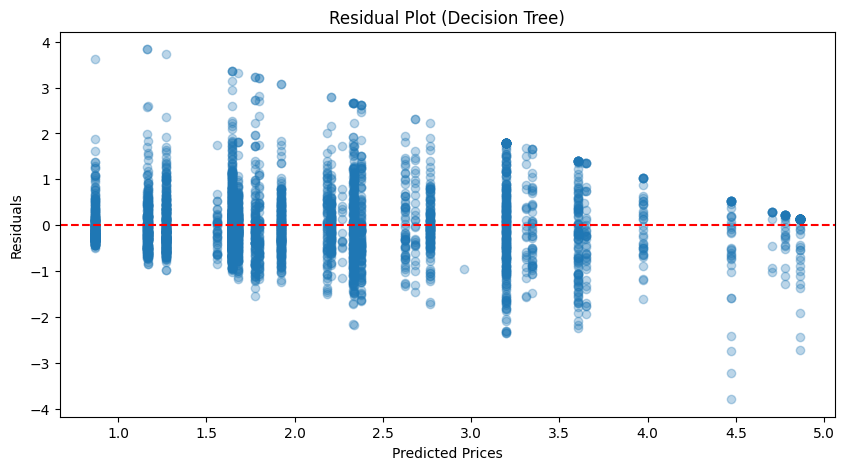

Model saved as best_california_housing_model.pkl


In [16]:
best_model_name = best_model_row['Model']
best_model = models[best_model_name]
y_pred = best_model.predict(X_test)

# Scatter Plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Actual vs Predicted House Prices ({best_model_name})')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.show()

# Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.title(f'Residual Plot ({best_model_name})')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.show()

# Save Model
joblib.dump(best_model, 'best_california_housing_model.pkl')
print("Model saved as best_california_housing_model.pkl")